In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage.io as io
import skimage.measure as measure
import skimage.morphology as morphology
import skimage.segmentation as segmentation
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
from skimage.color import label2rgb

To request:
https://www.nature.com/articles/s41567-023-02365-0?utm_source=chatgpt.com#data-availability
https://www.nature.com/articles/s41467-024-51573-6#data-availability
https://www.nature.com/articles/s41598-021-98556-x?utm_source=chatgpt.com#rightslink
https://www.nature.com/articles/s41563-024-02027-3#Sec3
https://pmc.ncbi.nlm.nih.gov/articles/PMC5876692/?utm_source=chatgpt.com#Abs1
https://pmc.ncbi.nlm.nih.gov/articles/PMC8450056/?utm_source=chatgpt.com#_ad93_
To download:
https://www.nature.com/articles/s41586-024-08287-y#Sec23 at https://data.4tu.nl/datasets/12631fa1-4fed-440d-acf3-676b97862034
https://data.4tu.nl/datasets/c4883858-a901-4e93-b716-2869a664acb0
https://gigadb.org/dataset/100118?utm_source=chatgpt.com


### Kolinski 2024

https://zenodo.org/records/10604552?utm_source=chatgpt.com

In [ ]:
kolinski_root = "data/Kolinski_et_al_2024/segmented_3D_crack_stacks/local_propagation/"
kolinski_files = list(sorted(Path(kolinski_root).glob("*.tif")))
kolinski_info = pd.read_excel("data/Kolinski_et_al_2024/segmented_3D_crack_stacks/sample_info.xlsx", sheet_name="local_propagation")

In [ ]:
for sample_name, sample_info in kolinski_info.groupby("sample"):
    #fig = go.Figure()
    #fig.update_layout(title=sample_name, scene=dict(
    #    xaxis_title='X (um)',
    #    yaxis_title='Y (um)',
    #    zaxis_title='Z (um)',
    #    aspectmode='data'))
    print(sample_name)
    boundaries_time_series = {'time': [], 'z': [], 'boundary': []}
    meshes = {}
    for sample_t_name, info in sample_info.iterrows():
        crack_name = info["crack_name"]
        crack_time = int(crack_name[crack_name.find("vol"):].replace("vol", ""))
        
        file_name = kolinski_root + crack_name + ".tif"
        z_start = info["s_start"]
        z_end = info["s_end"]
        data = io.imread(file_name)
        data = data[z_start:z_end]
        #plt.imshow(data[data.shape[0]//2])
        labelled_data = morphology.label(data)
        labels_data, counts_data = np.unique(labelled_data, return_counts=True)
        if labels_data[0] == 0:
            labels_data = labels_data[1:]
            counts_data = counts_data[1:]
        largest_label_data = labels_data[np.argmax(counts_data)]
        data = (labelled_data == largest_label_data).astype(float)
        crack_tips = []
        verts, faces, normals, values = measure.marching_cubes(data, level=0.5, spacing=(info['xy_scale_um'], info['xy_scale_um'], info['z_scale_um']))
        
        meshes[crack_time] = (verts, faces)
        nrows = 5
        ncols = int(np.ceil(len(data) / nrows))
        fig, axs = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
        axs = axs.flatten()
        for i in range(data.shape[0]):
            
            boundaries = segmentation.find_boundaries(data[i], mode='inner')
            labelled_boundaries = morphology.label(boundaries)
            labels, counts = np.unique(labelled_boundaries, return_counts=True)
            #plt.imshow(label2rgb(labelled_boundaries, bg_label=0))
            #plt.show()
            if labels[0] == 0:
                labels = labels[1:]
                counts = counts[1:]
            largest_label = labels[np.argmax(counts)]
            boundary = np.argwhere(labelled_boundaries == largest_label)
            xy_crack_tip = boundary[np.argmax(boundary[:, 1])]*info['xy_scale_um']
            crack_tip = np.array([ (z_start + i) * info['z_scale_um'], xy_crack_tip[0], xy_crack_tip[1] ])
            axs[i].imshow(data[i].T, cmap='gray', origin='lower')
            axs[i].plot(boundary[:, 0], boundary[:, 1], lw=3, c='r', label='Boundary')
            axs[i].scatter(xy_crack_tip[0]/info['xy_scale_um'], xy_crack_tip[1]/info['xy_scale_um'], c='b', s=100, label='Crack Tip')
            crack_tips.append(crack_tip)
            boundaries_time_series['time'].append(crack_time)
            boundaries_time_series['z'].append(z_start + i)
            boundaries_time_series['boundary'].append(boundary*info['xy_scale_um'])
        crack_tips = np.array(crack_tips)
        plt.show()
        #fig.add_trace(go.Scatter3d(x=crack_tips[:, 1], y=crack_tips[:, 2], z=crack_tips[:, 0], mode='markers', name=f'Time {crack_time}'))
        #plt.plot(crack_tips[:, 1], crack_tips[:, 2])
    #fig.show()
    boundaries_time_series = pd.DataFrame(boundaries_time_series)
    

In [ ]:
plt.imshow(data[0])
plt.show()
plt.imshow(data[10])

In [ ]:
for time in meshes.keys():
    verts, faces = meshes[time]
    fig = go.Figure(data=[go.Mesh3d(x=verts[:,0], y=verts[:,1], z=verts[:,2], i=faces[:,0], j=faces[:,1], k=faces[:,2])])
    fig.update_layout(title=f'Crack at time {time}', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
    fig.show()

In [ ]:
for z in boundaries_time_series.groupby("z"):
    fig = go.Figure()
    for time, group in z[1].groupby("time"):
        boundary = group['boundary'].values[0]
        fig.add_trace(go.Scatter(x=boundary[:,1], y=boundary[:,0], mode='markers', name=f'Time {time}'))
    fig.update_layout(title=f'Boundaries at z={z[0]}', xaxis_title='X', yaxis_title='Y')
    fig.show()

### Bergfeld 2021

https://www.envidat.ch/dataset/crack-propagation-in-weak-snowpack-layers-insights-from-high-speed-photography/resource/8f4b6eb5-b90e-4d09-b5ef-7b04eba94c94

### Snow

In [2]:
import netCDF4 as nc

In [3]:
data = nc.Dataset("data/Snow/PST1.nc")

In [4]:
crack_mask = np.asarray(data.variables['crack_mask'])
SL_mask = np.asarray(data.variables['SL_mask'])
SUB_mask = np.asarray(data.variables['SUB_mask'])
WL_mask = np.asarray(data.variables['WL_mask'])
saw_mask = np.asarray(data.variables['saw_mask'])
slide_mask = np.asarray(data.variables['slide_mask'])
x_rs_mcs = np.asarray(data.variables['x_rs_mcs'])
z_rs_mcs = np.asarray(data.variables['z_rs_mcs'])
disp_x_rs = np.asarray(data.variables['disp_x_rs'])
disp_z_rs = np.asarray(data.variables['disp_z_rs'])

In [14]:
disp_norm = np.sqrt(disp_z_rs**2 + disp_x_rs**2)
var =np.sqrt(np.diff(disp_x_rs, axis=0)**2 + np.diff(disp_z_rs, axis=0)**2)

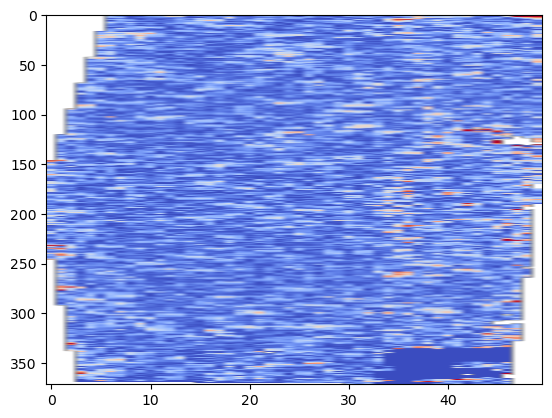

In [16]:
fig, ax = plt.subplots()
displ_im = ax.imshow(np.zeros_like(var[0]), vmin=np.nanquantile(var, 0.01), vmax=np.nanquantile(var, 0.99), cmap='coolwarm')
#ax.set_xlim(-1, n_cells+1)
ax.set_aspect('auto', adjustable='box')
display_handle = display(fig, display_id=True)
for time in range(0, var.shape[0],50):
    #diff = np.abs(disp_norm[time] - disp_norm[0]) > 1e-3
    #diff[~np.isfinite(diff)] = 0
    displ_im.set_data(var[time])
    display_handle.update(fig)
plt.close()